In [16]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

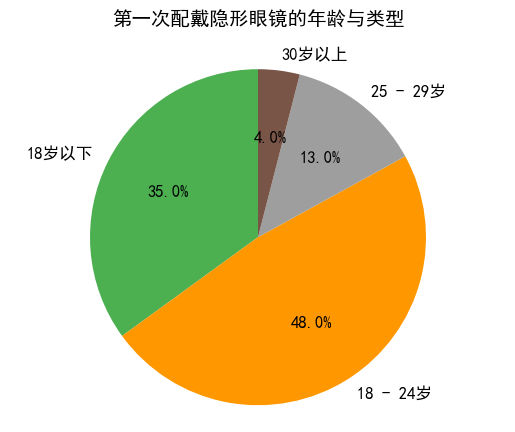

In [17]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

# 数据
labels = ['18岁以下', '18 - 24岁', '25 - 29岁', '30岁以上']
sizes = [35, 48, 13, 4]
# 颜色设置，尽量接近原图表
colors = ['#4CAF50', '#FF9800', '#9E9E9E', '#795548']  

# 创建饼图
fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%',
                                  startangle=90, colors=colors)

# 设置字体大小等样式，让显示更接近原图表
for text in texts + autotexts:
    text.set_fontsize(12)

# 以下为添加中间图片的大致流程，需将 'your_image_path.png' 替换为实际图片路径
# 假设图片是正方形且已处理好，这里只是示例，实际可能需要调整尺寸、位置等
# image = plt.imread('your_image_path.png')
# image_box = OffsetImage(image, zoom=0.3)  # zoom 调整图片大小
# ab = AnnotationBbox(image_box, (0, 0), frameon=False)
# ax.add_artist(ab)

# 设置图表标题
ax.set_title('第一次配戴隐形眼镜的年龄与类型', fontsize=14, y=1.05)

# 让饼图保持圆形
ax.axis('equal')

plt.show()

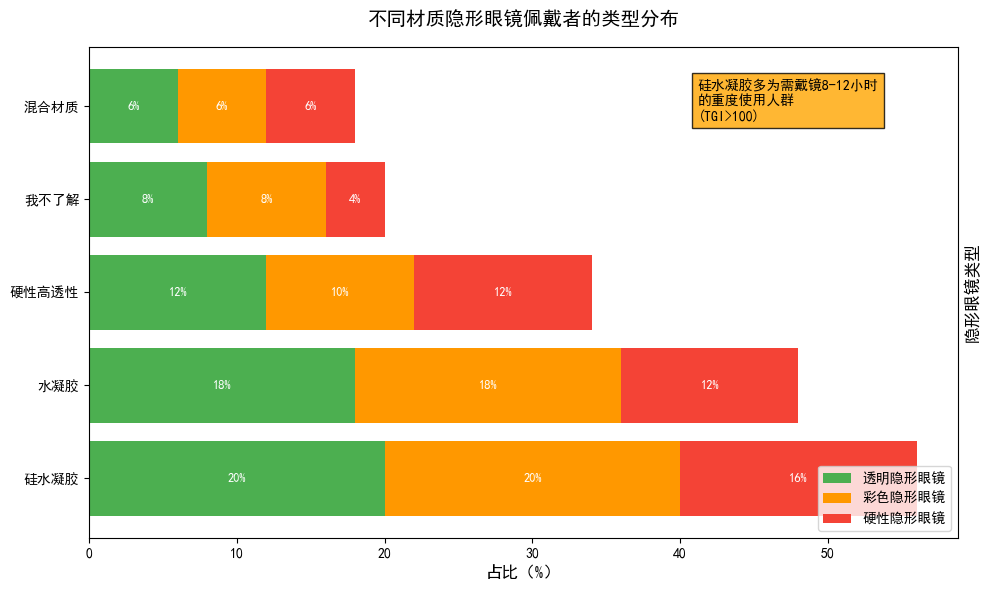

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 类别名称
categories = ["硅水凝胶", "水凝胶", "硬性高透性", "混合材质", "我不了解"]
# 各类别对应不同隐形眼镜类型的占比数据
data = np.array([
    [20, 20, 16],
    [18, 18, 12],
    [12, 10, 12],
    [6, 6, 6],
    [8, 8, 4]
])

# 计算每个类别的总数值
total_values = data.sum(axis=1)

# 根据总数值排序（降序）
sorted_indices = np.argsort(total_values)[::-1]

# 重新排列类别和数据
categories = [categories[i] for i in sorted_indices]
data = data[sorted_indices]

# 转置数据，让每列对应一种隐形眼镜类型
data = data.T

# 不同类型隐形眼镜的标签和对应颜色
labels = ["透明隐形眼镜", "彩色隐形眼镜", "硬性隐形眼镜"]
colors = ["#4CAF50", "#FF9800", "#F44336"]  

# 创建图表
fig, ax = plt.subplots(figsize=(10, 6))  # 适当增加宽度以容纳标签

# 绘制堆积条形图
bottom = np.zeros(len(categories))
for i in range(len(labels)):
    bars = ax.barh(categories, data[i], left=bottom, color=colors[i], label=labels[i])
    
    # 为每个条形添加数据标签
    for bar, value in zip(bars, data[i]):
        if value > 0:  # 只显示非零值
            ax.text(
                bar.get_x() + bar.get_width()/2,  # x 位置：条形中心
                bar.get_y() + bar.get_height()/2, # y 位置：条形中心
                f"{value}%",                      # 显示值和百分号
                ha='center', va='center',         # 水平和垂直居中
                color='white', fontweight='bold', # 白色文字，加粗
                fontsize=9                        # 字体大小
            )
    
    bottom += data[i]

# 添加注释文本（调整位置避免遮挡标签）
annotation_text = "硅水凝胶多为需戴镜8-12小时\n的重度使用人群\n(TGI>100)"
ax.text(0.7, 0.85, annotation_text, transform=ax.transAxes,
        bbox=dict(facecolor='orange', alpha=0.8), fontsize=10)

# 设置图表属性
ax.yaxis.set_label_position("right")
ax.set_ylabel("隐形眼镜类型", fontsize=12)
ax.set_xlabel("占比（%）", fontsize=12)
ax.set_title("不同材质隐形眼镜佩戴者的类型分布", fontsize=14, pad=15)
ax.legend(loc='lower right')  # 调整图例位置
plt.tight_layout()
plt.show()

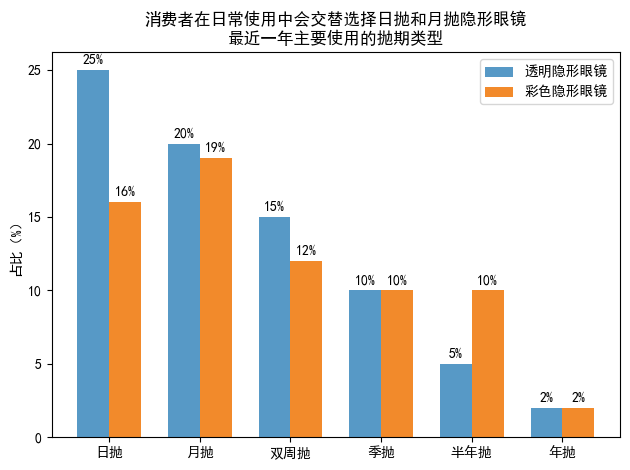

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 抛期类型
categories = ['日抛', '月抛', '双周抛', '季抛', '半年抛', '年抛']
# 透明隐形眼镜占比（模拟数据，大体接近示例比例）
transparent = [25, 20, 15, 10, 5, 2]  
# 彩色隐形眼镜占比（模拟数据，用总和约为示例中对应抛期的比例，如日抛总和约41% ）
colorful = [16, 19, 12, 10, 10, 2]  

x = np.arange(len(categories))  # x轴位置
width = 0.35  # 每个分组中条形的宽度

fig, ax = plt.subplots()
# 绘制透明隐形眼镜的条形
rects1 = ax.bar(x - width/2, transparent, width, label='透明隐形眼镜', color='#5799C6')  
# 绘制彩色隐形眼镜的条形
rects2 = ax.bar(x + width/2, colorful, width, label='彩色隐形眼镜', color='#F28A2B')  

# 设置x轴刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(categories)
# 设置y轴标签
ax.set_ylabel('占比（%）')  
# 设置标题
ax.set_title('消费者在日常使用中会交替选择日抛和月抛隐形眼镜\n最近一年主要使用的抛期类型')  
ax.legend()

# 在每个条形上方标注数值
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}%'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 数值标注相对于条形的垂直偏移
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

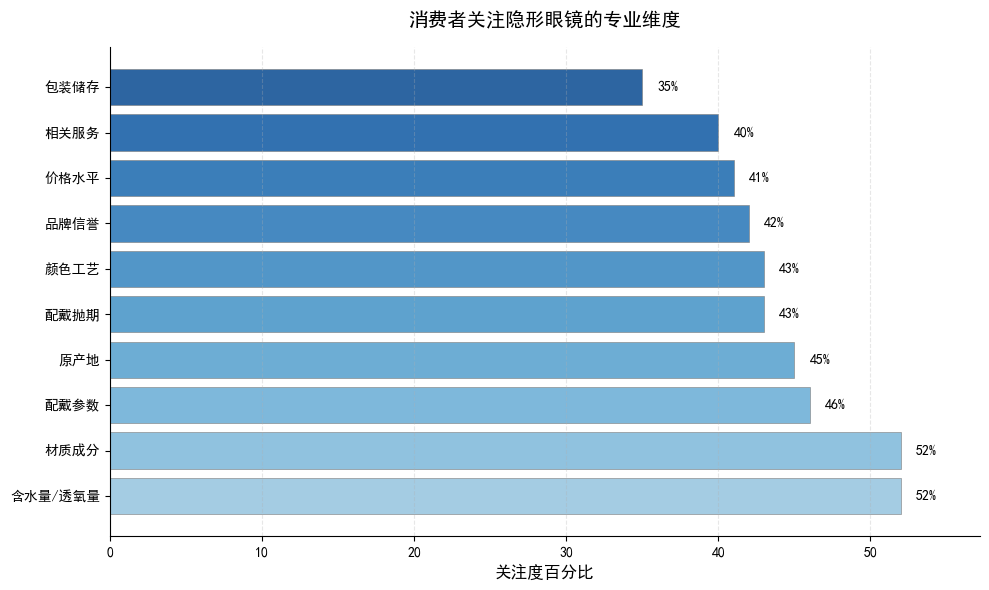

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ['含水量/透氧量', '材质成分', '配戴参数', '原产地', '配戴抛期', '颜色工艺', '品牌信誉', '价格水平', '相关服务', '包装储存']
values = [52, 52, 46, 45, 43, 43, 42, 41, 40, 35]

# 定义y轴位置
y_pos = np.arange(len(labels))

# 优化的渐变色方案（从深蓝到浅蓝）
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(labels)))

# 创建图形（增加尺寸）
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制横向条形图（增加边距和透明度）
bars = ax.barh(y_pos, values, color=colors, alpha=0.85, edgecolor='gray', linewidth=0.5)

# 设置y轴标签（增加标签间距）
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)

# 设置x轴标签和标题
ax.set_xlabel('关注度百分比', fontsize=12)
ax.set_title('消费者关注隐形眼镜的专业维度', fontsize=14, pad=15)

# 优化数值标签（增加字体大小和颜色）
for i, v in enumerate(values):
    ax.text(v + 1, i, f'{v}%', va='center', fontsize=10, color='black')

# 添加网格线（更轻的网格）
ax.grid(axis='x', linestyle='--', alpha=0.3)

# 设置x轴范围（增加边距）
ax.set_xlim(0, max(values) * 1.1)

# 美化边框（隐藏顶部和右侧边框）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()    